In [28]:
# importing the three main libraries we need for this assignment
# numpy for matrix math, pandas for data handling, matplotlib for plots
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# setting seed so results are reproducible every time we run
np.random.seed(42)
print("libraries loaded")

libraries loaded


In [29]:
# price data for two stocks over 12 months given in the question
prices = np.array([
    [100, 108, 103, 115, 110, 119, 125, 121, 130, 127, 135, 140],  # Stock A
    [200, 195, 210, 205, 220, 215, 225, 230, 222, 235, 240, 238]   # Stock B
])

# computing simple returns using the formula R_t = (P_t - P_{t-1}) / P_{t-1}
# prices[:,1:] gives columns 1 to end (current month)
# prices[:,:-1] gives columns 0 to second last (previous month)
# this is fully vectorised - no loops needed, result shape is (2, 11)
returns = (prices[:, 1:] - prices[:, :-1]) / prices[:, :-1]

print("Monthly Returns shape:", returns.shape)
print("Stock A returns:", np.round(returns[0], 4))
print("Stock B returns:", np.round(returns[1], 4))

Monthly Returns shape: (2, 11)
Stock A returns: [ 0.08   -0.0463  0.1165 -0.0435  0.0818  0.0504 -0.032   0.0744 -0.0231
  0.063   0.037 ]
Stock B returns: [-0.025   0.0769 -0.0238  0.0732 -0.0227  0.0465  0.0222 -0.0348  0.0586
  0.0213 -0.0083]


In [30]:
# to annualise monthly figures:
# mean return  -> multiply by 12 (12 months in a year)
# std dev      -> multiply by sqrt(12) — this comes from variance scaling with time
# using ddof=1 here to compute the sample std (same convention as np.cov below)
# ddof=0 would give population std which is inconsistent with np.cov's default
ann_mean = returns.mean(axis=1) * 12
ann_std  = returns.std(axis=1, ddof=1) * np.sqrt(12)

print("Annualised Mean Return -> Stock A: {:.2%}  Stock B: {:.2%}".format(ann_mean[0], ann_mean[1]))
print("Annualised Std Dev     -> Stock A: {:.2%}  Stock B: {:.2%}".format(ann_std[0], ann_std[1]))

Annualised Mean Return -> Stock A: 39.09%  Stock B: 20.07%
Annualised Std Dev     -> Stock A: 20.20%  Stock B: 14.58%


In [31]:
# np.cov computes the sample covariance matrix using ddof=1 by default
# so we must also use ddof=1 when computing std manually, otherwise the
# off-diagonal check won't match
cov_matrix = np.cov(returns)
print("Covariance Matrix:\n", np.round(cov_matrix, 6))

# verifying that the off-diagonal entry equals rho * sigA * sigB
# using ddof=1 to match np.cov's internal calculation
sigA = returns[0].std(ddof=1)
sigB = returns[1].std(ddof=1)
rho  = np.corrcoef(returns)[0, 1]

manual_cov = rho * sigA * sigB
print("\nManual check (rho * sigA * sigB) =", round(manual_cov, 6))
print("np.cov off-diagonal               =", round(cov_matrix[0, 1], 6))
# both values should match — confirming Cov(A,B) = rho * sigA * sigB

Covariance Matrix:
 [[ 0.0034   -0.002064]
 [-0.002064  0.001772]]

Manual check (rho * sigA * sigB) = -0.002064
np.cov off-diagonal               = -0.002064


In [32]:
# 3-asset parameters from Question 6
# mu holds expected returns, Sigma is the covariance matrix we built earlier
mu = np.array([0.15, 0.08, 0.05])

Sigma = np.array([
    [0.0625,  0.0120,  0.0010 ],
    [0.0120,  0.0144,  0.00096],
    [0.0010,  0.00096, 0.0016 ]
])

# equal weight means 1/3 in each asset
w_equal = np.array([1/3, 1/3, 1/3])

# portfolio expected return = w^T * mu  (dot product)
# portfolio variance = w^T * Sigma * w  (quadratic form)
port_return = w_equal @ mu
port_var    = w_equal @ Sigma @ w_equal
port_std    = np.sqrt(port_var)

print("Equal Weight Portfolio")
print("Expected Return : {:.4f}".format(port_return))
print("Variance        : {:.6f}".format(port_var))
print("Std Dev         : {:.4f}".format(port_std))

Equal Weight Portfolio
Expected Return : 0.0933
Variance        : 0.011824
Std Dev         : 0.1087


In [33]:
# generating 10000 random weight vectors using dirichlet distribution
# dirichlet with alpha=ones guarantees weights are positive and sum to 1
# result shape is (10000, 3) — one weight vector per row
rand_weights = np.random.dirichlet(np.ones(3), size=10000)

# portfolio returns: simple matrix multiply, shape (10000,)
port_returns = rand_weights @ mu

# portfolio std: using einsum to do w^T Sigma w for all 10000 at once
# einsum 'ij,jk,ik->i' computes the quadratic form row by row, no python loop
port_stds = np.sqrt(np.einsum('ij,jk,ik->i', rand_weights, Sigma, rand_weights))

print("Sample of portfolio returns:", np.round(port_returns[:5], 4))
print("Sample of portfolio stds   :", np.round(port_stds[:5], 4))
print("Shapes:", port_returns.shape, port_stds.shape)

Sample of portfolio returns: [0.0786 0.127  0.0722 0.076  0.1335]
Sample of portfolio stds   : [0.0908 0.1901 0.0862 0.074  0.2066]
Shapes: (10000,) (10000,)


In [34]:
# risk free rate from question 7
Rf = 0.04

# computing sharpe ratio for all 10000 portfolios in one vectorised step
# sharpe = (E[Rp] - Rf) / sigma_p
sharpe_ratios = (port_returns - Rf) / port_stds

# finding the portfolio with the highest sharpe ratio
max_idx = np.argmax(sharpe_ratios)

print("Max Sharpe Ratio : {:.4f}".format(sharpe_ratios[max_idx]))
print("Best Weights     :", np.round(rand_weights[max_idx], 4))
print("Return at max    : {:.4f}".format(port_returns[max_idx]))
print("Risk at max      : {:.4f}".format(port_stds[max_idx]))

Max Sharpe Ratio : 0.5053
Best Weights     : [0.2034 0.1715 0.6251]
Return at max    : 0.0755
Risk at max      : 0.0702


In [35]:
# two asset parameters from question 12
mu1, sig1 = 0.12, 0.20
mu2, sig2 = 0.06, 0.10
w1 = 0.6
w2 = 1 - w1

# 200 equally spaced correlation values from -1 to +1
rho_values = np.linspace(-1, 1, 200)

# computing portfolio variance for each rho value using the formula
# sigma_p^2 = w1^2*sig1^2 + w2^2*sig2^2 + 2*w1*w2*rho*sig1*sig2
# fully vectorised since rho_values is a numpy array — no loops
port_var_arr = (w1**2 * sig1**2
              + w2**2 * sig2**2
              + 2 * w1 * w2 * rho_values * sig1 * sig2)

port_std_arr = np.sqrt(port_var_arr)

# finding which rho gives the minimum portfolio std
min_idx = np.argmin(port_std_arr)
print("Min portfolio std : {:.4f} at rho = {:.4f}".format(
       port_std_arr[min_idx], rho_values[min_idx]))

Min portfolio std : 0.0800 at rho = -1.0000


In [36]:
# analytically differentiating sigma_p^2 with respect to rho gives:
# d(sigma_p^2)/d(rho) = 2 * w1 * w2 * sig1 * sig2
# this derivative is always positive since all terms are positive
# meaning variance always increases as rho increases
# so the minimum variance must occur at the left boundary: rho = -1

deriv = 2 * w1 * w2 * sig1 * sig2
print("d(variance)/d(rho) = {:.4f}  (always positive)".format(deriv))
print("So portfolio variance is increasing in rho.")
print("Minimum always occurs at rho = -1 (boundary).")

# confirming numerically at rho = -1
sig_at_minus1 = np.sqrt(w1**2*sig1**2 + w2**2*sig2**2 + 2*w1*w2*(-1)*sig1*sig2)
print("Analytical sigma_p at rho=-1 : {:.4f}".format(sig_at_minus1))

d(variance)/d(rho) = 0.0096  (always positive)
So portfolio variance is increasing in rho.
Minimum always occurs at rho = -1 (boundary).
Analytical sigma_p at rho=-1 : 0.0800


In [37]:
# resetting seed to 0 as specified in the assignment skeleton for Q13
np.random.seed(0)

# creating 52 weekly dates starting from Jan 2023
dates = pd.date_range('2023-01-02', periods=52, freq='W-MON')

# weekly drift and volatility for 4 simulated assets
mu_weekly  = np.array([0.003, 0.002, 0.001, 0.0015])
sig_weekly = np.array([0.04,  0.03,  0.02,  0.025 ])

# simulating weekly returns from a normal distribution
# then computing cumulative price path starting at 100
returns_sim = np.random.normal(mu_weekly, sig_weekly, (52, 4))
prices_sim  = 100 * np.cumprod(1 + returns_sim, axis=0)

df = pd.DataFrame(prices_sim, index=dates,
                  columns=['AAPL', 'MSFT', 'GOOGL', 'AMZN'])

# pct_change gives us simple weekly returns, dropna removes the first NaN row
df_returns = df.pct_change().dropna()

print("Shape:", df_returns.shape)
print(df_returns.head(3))

Shape: (51, 4)
                AAPL      MSFT     GOOGL      AMZN
2023-01-09  0.077702 -0.027318  0.020002 -0.002284
2023-01-16 -0.001129  0.014318  0.003881  0.037857
2023-01-23  0.033442  0.005650  0.009877  0.009842


In [38]:
# summary statistics for all four assets
print(df_returns.describe())

# identifying which asset has the highest mean return and highest volatility
print("\nHighest mean return  :", df_returns.mean().idxmax())
print("Highest std dev      :", df_returns.std().idxmax())

# computing annualised sharpe ratio using weekly data
# weekly rf = annual rf / 52
# annualised sharpe = (weekly mean - weekly rf) / weekly std  * sqrt(52)
Rf_weekly = 0.02 / 52
sharpe_assets = (df_returns.mean() - Rf_weekly) / df_returns.std() * np.sqrt(52)
print("\nAnnualised Sharpe Ratios:\n", sharpe_assets.round(4))

            AAPL       MSFT      GOOGL       AMZN
count  51.000000  51.000000  51.000000  51.000000
mean    0.005603   0.002192  -0.000887   0.006094
std     0.045641   0.032819   0.017055   0.022948
min    -0.099120  -0.057424  -0.033125  -0.054085
25%    -0.030293  -0.025056  -0.013135  -0.006813
50%     0.001429  -0.002650  -0.000365   0.009468
75%     0.039082   0.028178   0.009462   0.020051
max     0.098326   0.060309   0.044265   0.050269

Highest mean return  : AMZN
Highest std dev      : AAPL

Annualised Sharpe Ratios:
 AAPL     0.8245
MSFT     0.3971
GOOGL   -0.5376
AMZN     1.7940
dtype: float64


In [39]:
# (a) correlation matrix across all four assets
corr_matrix = df_returns.corr()
print("Correlation Matrix:\n", corr_matrix.round(4))

# extracting only upper triangle to avoid counting pairs twice
# then finding the pair with the lowest correlation
corr_vals = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
min_pair  = corr_vals.stack().idxmin()
print("\nLowest correlation pair:", min_pair)

# (b) equal weight portfolio return series
# dot product of returns dataframe with weight series gives one return per week
weights = pd.Series([0.25, 0.25, 0.25, 0.25], index=df_returns.columns)
port_series = df_returns.dot(weights)
print("\nPortfolio return series (first 5):\n", port_series.head())

# (c) resampling weekly returns to monthly
# compounding weekly returns properly: (1+r1)(1+r2)... - 1
monthly_returns = port_series.resample('ME').apply(lambda x: (1 + x).prod() - 1)

print("Monthly Returns:\n", monthly_returns.round(4))
print("\nMean monthly return :", round(monthly_returns.mean(), 4))
print("Std  monthly return :", round(monthly_returns.std(),  4))

Correlation Matrix:
          AAPL    MSFT   GOOGL    AMZN
AAPL   1.0000 -0.0753  0.1907  0.0601
MSFT  -0.0753  1.0000  0.2873  0.0695
GOOGL  0.1907  0.2873  1.0000 -0.0013
AMZN   0.0601  0.0695 -0.0013  1.0000

Lowest correlation pair: ('AAPL', 'MSFT')

Portfolio return series (first 5):
 2023-01-09    0.017025
2023-01-16    0.013732
2023-01-23    0.014703
2023-01-30    0.011504
2023-02-06   -0.019069
Freq: W-MON, dtype: float64
Monthly Returns:
 2023-01-31    0.0582
2023-02-28    0.0014
2023-03-31   -0.0223
2023-04-30   -0.0368
2023-05-31    0.0118
2023-06-30    0.0519
2023-07-31    0.0847
2023-08-31    0.0120
2023-09-30    0.0088
2023-10-31    0.0215
2023-11-30   -0.0497
2023-12-31    0.0263
Freq: ME, dtype: float64

Mean monthly return : 0.014
Std  monthly return : 0.039


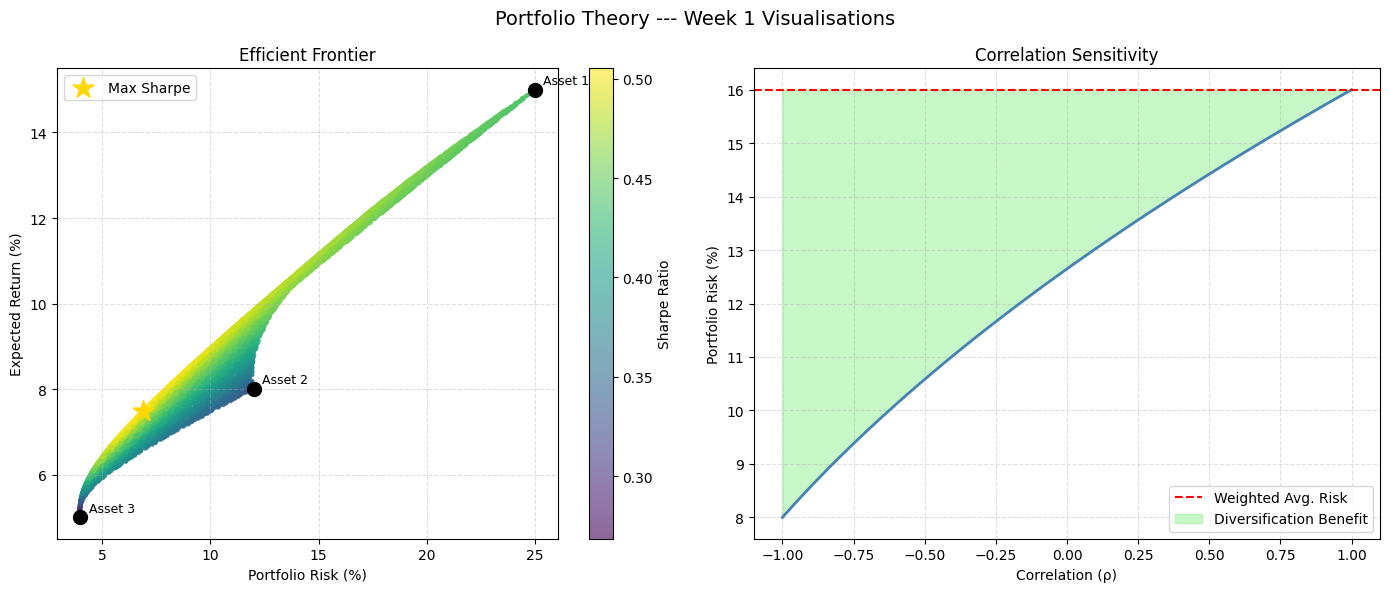

Plot saved as week1_plots.png


In [40]:
# simulating 20000 random portfolios for the efficient frontier plot
N = 20000
w_sim   = np.random.dirichlet(np.ones(3), size=N)
er_sim  = w_sim @ mu
std_sim = np.sqrt(np.einsum('ij,jk,ik->i', w_sim, Sigma, w_sim))
sr_sim  = (er_sim - 0.04) / std_sim

# index of the portfolio with the highest sharpe ratio
best = np.argmax(sr_sim)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Portfolio Theory --- Week 1 Visualisations', fontsize=14)

# --- subplot 1: efficient frontier scatter ---
# colouring each point by its sharpe ratio using viridis colormap
sc = ax1.scatter(std_sim * 100, er_sim * 100, c=sr_sim,
                 cmap='viridis', s=5, alpha=0.6)

# marking the best sharpe portfolio with a gold star
ax1.scatter(std_sim[best]*100, er_sim[best]*100,
            marker='*', s=250, color='gold', zorder=5, label='Max Sharpe')

# plotting individual assets as dark circles and labelling them
# using np.diag to extract diagonal variances — fully vectorised, no python loop
asset_labels = ['Asset 1', 'Asset 2', 'Asset 3']
asset_stds   = np.sqrt(np.diag(Sigma)) * 100
asset_rets   = mu * 100

for i in range(3):
    ax1.scatter(asset_stds[i], asset_rets[i], s=100, color='black', zorder=6)
    ax1.annotate(asset_labels[i], (asset_stds[i], asset_rets[i]),
                 textcoords="offset points", xytext=(6, 4), fontsize=9)

# adding colorbar and axis labels
cbar = plt.colorbar(sc, ax=ax1)
cbar.set_label('Sharpe Ratio')
ax1.set_xlabel('Portfolio Risk (%)')
ax1.set_ylabel('Expected Return (%)')
ax1.set_title('Efficient Frontier')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.4)

# --- subplot 2: correlation sensitivity ---
# using the same two asset parameters from Q12
rho_arr = np.linspace(-1, 1, 200)
std_arr = np.sqrt(w1**2*sig1**2 + w2**2*sig2**2 + 2*w1*w2*rho_arr*sig1*sig2) * 100

# weighted average risk — this is what portfolio risk would be with no diversification
# i.e. when rho = 1, sigma_p = w1*sig1 + w2*sig2
w_avg = (w1 * sig1 + w2 * sig2) * 100

ax2.plot(rho_arr, std_arr, color='steelblue', linewidth=2)
ax2.axhline(w_avg, color='red', linestyle='--', label='Weighted Avg. Risk')

# shading the region where portfolio risk is below the weighted average
# interpolate=True makes sure the boundary is handled cleanly
# where the curve meets the red line, no overflow into rest of the plot
ax2.fill_between(rho_arr, std_arr, w_avg,
                 where=(std_arr <= w_avg),
                 interpolate=True,
                 color='lightgreen', alpha=0.5,
                 label='Diversification Benefit')

ax2.set_xlabel('Correlation (ρ)')
ax2.set_ylabel('Portfolio Risk (%)')
ax2.set_title('Correlation Sensitivity')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('week1_plots.png', dpi=150)
plt.show()
print("Plot saved as week1_plots.png")